<a href="https://colab.research.google.com/github/soumnemishra/snap_tune/blob/main/Snap_tune_project_model_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow scikit-learn opencv-python-headless tqdm -q

In [2]:
import os #OS FOR NAVIGATING THROUGH THE FILES
import matplotlib.pyplot as plt #MATPLOTLIB FOR PLOTTING GRAPHS
import seaborn as sns #SEABORN FOR DATA VISUALIZATION
from PIL import Image #PILLOW FOR IMAGE PROCESSING
import pandas as pd #PANDAS FOR data manipulation and data analysis
import numpy as np #NUMPY FOR NUMERICAL OPERATIONS

import hashlib #HASHLIB FOR CHECKING DUPLICATES
from collections import defaultdict #DEFAULTDICT FOR CREATING A DICTIONARY WITH DEFAULT VALUES



import tensorflow as tf
from tensorflow.keras.applications import resnet50
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

import glob


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ORIGINAL DATA SETS

# Acessing the total folders

In [4]:
Trainign_='/content/drive/MyDrive/snap_tune_project/original_datasets/train' #TRAINING FOLDER
Testing_='/content/drive/MyDrive/snap_tune_project/original_datasets/test' #TESTING FOLDER

# TRAINING FOLDER

In [11]:

#the base folder
base_folder = Trainign_
# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
counts = {}
total_images = 0 # Initialize a counter for the total number of images

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count
    total_images += count # Add the count from each class to the total

print(f"Total number of images in {Trainign_}: {total_images}") # Print the total count

#print the counts per class as before if you still need them
print(counts)

Total number of images in /content/drive/MyDrive/snap_tune_project/original_datasets/train: 28729
{'angry': 4005, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3181}


# CHECKING FOR DUPLICATES

In [13]:
# Base folder path
base_folder = Trainign_
# Subfolders / emotion classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Dictionary to store image hashes and their paths
hash_dict = defaultdict(list)

# Function to compute SHA256 hash of an image
def get_image_hash(image_path):
    with open(image_path, 'rb') as f:
        return hashlib.sha256(f.read()).hexdigest()

# Traverse each class folder and hash each image
for cls in classes:
    class_path = os.path.join(base_folder, cls)
    for filename in os.listdir(class_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif')):
            filepath = os.path.join(class_path, filename)
            try:
                img_hash = get_image_hash(filepath)
                hash_dict[img_hash].append(filepath)
            except Exception as e:
                print(f"Error processing {filepath}: {e}")

# Find and print duplicates
duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

print(f"\nFound {len(duplicates)} sets of duplicate images.")

for i, (h, paths) in enumerate(duplicates.items(), 1):
    print(f"\nDuplicate set {i}:")
    for p in paths:
        print(f"  {p}")

KeyboardInterrupt: 

# VISUALLY DISTRIBUTIONS OF THE TRAINING CLASSES

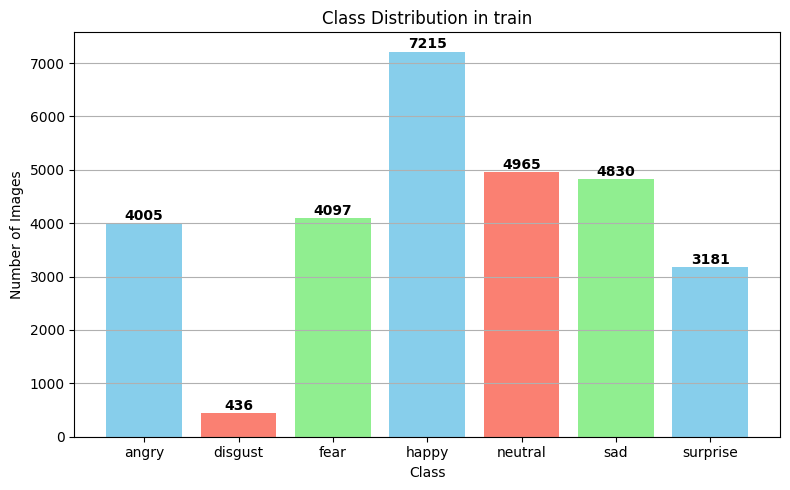

In [14]:


#VISUALING CLASS DISTRIBUTION OF Training IMAGES
base_folder_mask = Trainign_
# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder_mask, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.keys(), counts.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.title(f'Class Distribution in {os.path.basename(base_folder_mask)}')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(axis='y')

# Add counts on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 2, str(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# Test Classes

In [15]:

#the base folder
base_folder = Testing_
# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
counts = {}
total_images = 0 # Initialize a counter for the total number of images

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count
    total_images += count # Add the count from each class to the total

print(f"Total number of images in {Testing_}: {total_images}") # Print the total count

# You can also print the counts per class as before if you still need them
print(counts)

Total number of images in /content/drive/MyDrive/snap_tune_project/original_datasets/test: 7178
{'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


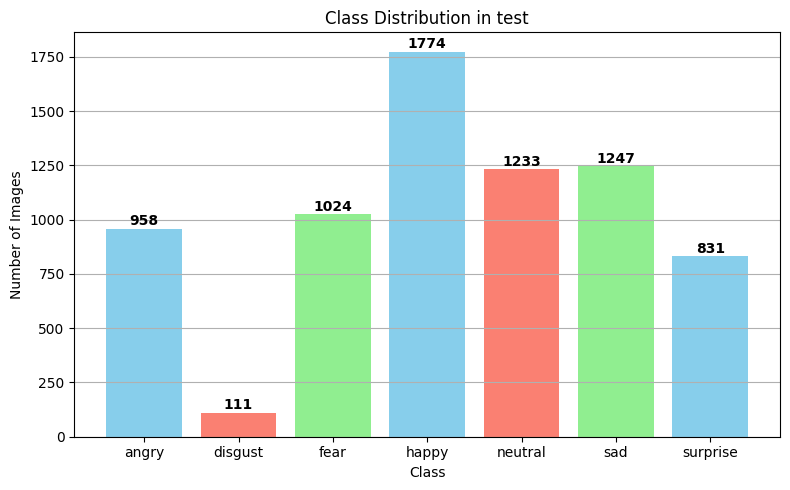

In [6]:
#VISUALING CLASS DISTRIBUTION OF Training IMAGES
base_folder_mask = Testing_
# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Count number of images in each subfolder
counts = {} # Initialize counts here
for cls in classes:
    class_path = os.path.join(base_folder_mask, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.keys(), counts.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.title(f'Class Distribution in {os.path.basename(base_folder_mask)}')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(axis='y')

# Add counts on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 2, str(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# VISUALIZING DATA SETS AFTER REMOVING DUPLICATES

TRAINING FOLDER

In [7]:
training_remove_='/content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train'
#the base folder
base_folder = training_remove_

# Subfolders / classes
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
counts = {}
total_images = 0 # Initialize a counter for the total number of images

# Count number of images in each subfolder
for cls in classes:
    class_path = os.path.join(base_folder, cls)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
    counts[cls] = count
    total_images += count # Add the count from each class to the total

print(f"Total number of images in {Trainign_}: {total_images}") # Print the total count

#print the counts per class as before if you still need them
print(counts)

Total number of images in /content/drive/MyDrive/snap_tune_project/original_datasets/train: 27473
{'angry': 3849, 'disgust': 381, 'fear': 3904, 'happy': 7086, 'neutral': 4868, 'sad': 4716, 'surprise': 2669}


# Testing Folder

In [8]:
testing_remove_='/content/drive/MyDrive/snap_tune_project/cleaned_fer2013/test'
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
for base_folder, folder_name in [(testing_remove_, 'test')]:
    counts = {}
    total_images = 0
    if not os.path.exists(base_folder):
        print(f"Warning: {base_folder} does not exist. Skipping count.")
        continue
    for cls in emotions:
        class_path = os.path.join(base_folder, cls)
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])
        counts[cls] = count
        total_images += count
    print(f"Total number of images in {base_folder}: {total_images}")
    print(f"Counts per class in {folder_name}: {counts}")

Total number of images in /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/test: 6561
Counts per class in test: {'angry': 888, 'disgust': 79, 'fear': 922, 'happy': 1711, 'neutral': 1182, 'sad': 1198, 'surprise': 581}


# Preprocessing

In [9]:
# Install required libraries
!pip install tensorflow scikit-learn opencv-python-headless tqdm -q

import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import resnet50
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from google.colab import drive
import glob

# Step 1: Configuration and Validation
print("Step 1: Setting up configuration and validating dataset...")
config = {
    'data_dir': '/content/drive/MyDrive/snap_tune_project/cleaned_fer2013',
    'img_size': (224, 224),  # ResNet50 input size
    'batch_size': 32,       # Optimized for GPU (T4) - Reduced batch size
    'chunk_size': 5000,     # Process 5,000 images per chunk
    'train_dir': os.path.join('/content/drive/MyDrive/snap_tune_project/cleaned_fer2013', 'train'),
    'test_dir': os.path.join('/content/drive/MyDrive/snap_tune_project/cleaned_fer2013', 'test')
}

# Preprocessor for ResNet50
def preprocess_image(image):
    if image is None:
        raise ValueError("Image decoding failed, image is None")
    image = tf.image.resize(image, config['img_size'])  # Resize to 224x224
    image.set_shape([224, 224, 1])  # Explicitly set shape (grayscale)
    image = tf.image.grayscale_to_rgb(image)  # Convert to RGB
    image = resnet50.preprocess_input(image)  # Normalize [-1, 1]
    return image

# Mount Google Drive
drive.mount('/content/drive')

# Validate directories
if not os.path.exists(config['data_dir']):
    raise FileNotFoundError(f"Dataset directory {config['data_dir']} does not exist.")
if not os.path.exists(config['train_dir']):
    raise FileNotFoundError(f"Train directory {config['train_dir']} does not exist.")
if not os.path.exists(config['test_dir']):
    raise FileNotFoundError(f"Test directory {config['test_dir']} does not exist.")
print(f"Directories validated: {config['train_dir']}, {config['test_dir']}")

# Define emotion classes
emotion_classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Step 2: Collect Image Paths and Labels for Train Set
print("\nStep 2: Collecting image paths and labels for train set...")
train_image_paths = []
train_labels = []
for class_name in emotion_classes:
    class_dir = os.path.join(config['train_dir'], class_name)
    if not os.path.exists(class_dir):
        print(f"Warning: Class directory {class_dir} is missing. Skipping...")
        continue
    found_files = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif']:
        found_files.extend(glob.glob(os.path.join(class_dir, ext)))
    print(f"Found {len(found_files)} files in {class_dir} before verification.")
    if not found_files:
        print(f"Warning: No files found in {class_dir}. Skipping this class.")
        continue
    with tqdm(total=len(found_files), desc=f"Verifying {class_name} (train)") as pbar:
        for img_path in found_files:
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
                train_image_paths.append(img_path)
                train_labels.append(class_name)
            except Exception as e:
                print(f"Skipping corrupted image: {img_path}, Error: {e}")
            pbar.update(1)

train_image_paths = np.array(train_image_paths)
train_labels = np.array(train_labels)

if len(train_image_paths) == 0:
    raise FileNotFoundError(f"No valid images found in {config['train_dir']}.")
print(f"Successfully loaded {len(train_image_paths)} images from train set.")

# Step 3: Split Train Data into Training and Validation Sets
print("\nStep 3: Splitting train data into training and validation sets...")
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
train_paths, val_paths, train_labels_enc, val_labels_enc = train_test_split(
    train_image_paths, train_labels_encoded, train_size=0.7, stratify=train_labels_encoded, random_state=42
)
print(f"Training samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")

# Step 4: Collect Image Paths and Labels for Test Set
print("\nStep 4: Collecting image paths and labels for test set...")
test_image_paths = []
test_labels = []
for class_name in emotion_classes:
    class_dir = os.path.join(config['test_dir'], class_name)
    if not os.path.exists(class_dir):
        print(f"Warning: Test class directory {class_dir} is missing. Skipping...")
        continue
    found_files = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif']:
        found_files.extend(glob.glob(os.path.join(class_dir, ext)))
    print(f"Found {len(found_files)} files in {class_dir} before verification.")
    if not found_files:
        print(f"Warning: No files found in {class_dir}. Skipping this class.")
        continue
    with tqdm(total=len(found_files), desc=f"Verifying {class_name} (test)") as pbar:
        for img_path in found_files:
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity
                test_image_paths.append(img_path)
                test_labels.append(class_name)
            except Exception as e:
                print(f"Skipping corrupted image: {img_path}, Error: {e}")
            pbar.update(1)

test_image_paths = np.array(test_image_paths)
test_labels = np.array(test_labels)

if len(test_image_paths) == 0:
    raise FileNotFoundError(f"No valid images found in {config['test_dir']}.")
print(f"Successfully loaded {len(test_image_paths)} images from test set.")

# Step 5: Create TFRecord Writing Function
print("\nStep 5: Defining TFRecord writing function...")
def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def create_tfrecord(paths, labels, output_path):
    with tf.io.TFRecordWriter(output_path) as writer:
        for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Writing TFRecord to {output_path}"):
            try:
                img = tf.io.read_file(path)
                img = tf.image.decode_image(img, channels=1, expand_animations=False)
                img = tf.ensure_shape(img, [None, None, 1], name="ensure_image_shape")
                img = preprocess_image(img)
                img_bytes = tf.io.serialize_tensor(img).numpy()
                example = tf.train.Example(features=tf.train.Features(feature={
                    'image': _bytes_feature(img_bytes),
                    'label': _int64_feature(label)
                }))
                writer.write(example.SerializeToString())
            except Exception as e:
                print(f"Skipping invalid image: {path}, Error: {e}")

# Step 6: Process and Save Datasets in Chunks
print("\nStep 6: Processing and saving datasets in chunks...")
def process_in_chunks(paths, labels, dataset_type, preprocessed_dir):
    num_chunks = max(1, len(paths) // config['chunk_size'] + 1)
    for i in range(num_chunks):
        start_idx = i * config['chunk_size']
        end_idx = min((i + 1) * config['chunk_size'], len(paths))
        chunk_paths = paths[start_idx:end_idx]
        chunk_labels = labels[start_idx:end_idx]
        if len(chunk_paths) == 0:
            continue
        chunk_output = os.path.join(preprocessed_dir, f'{dataset_type}_chunk_{i}.tfrecord')
        print(f"Processing {dataset_type} chunk {i+1}/{num_chunks} ({len(chunk_paths)} images)...")
        create_tfrecord(chunk_paths, chunk_labels, chunk_output)
    print(f"Finished processing {dataset_type} dataset.")

# Create preprocessed directory
preprocessed_dir = os.path.join(config['data_dir'], 'preprocessed')
os.makedirs(preprocessed_dir, exist_ok=True)

# Process train, validation, and test datasets
try:
    process_in_chunks(train_paths, train_labels_enc, 'train', preprocessed_dir)
    process_in_chunks(val_paths, val_labels_enc, 'val', preprocessed_dir)
    process_in_chunks(test_image_paths, le.transform(test_labels), 'test', preprocessed_dir)
except Exception as e:
    print(f"Error processing chunks: {e}")
    print("Check disk space in Google Drive or /tmp, or reduce chunk_size.")

# Step 7: Compute Class Weights
print("\nStep 7: Computing class weights...")
class_weights = np.zeros(len(emotion_classes))
for label in train_labels_enc:
    class_weights[label] += 1
class_weights = len(train_labels_enc) / (len(emotion_classes) * class_weights)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Class weights: {class_weight_dict}")

# Step 8: Save Class Weights and Label Encoder
print("\nStep 8: Saving class weights and label encoder...")
try:
    np.save(os.path.join(preprocessed_dir, 'class_weights.npy'), class_weight_dict)
    np.save(os.path.join(preprocessed_dir, 'label_encoder.npy'), le.classes_)
    print("Class weights and label encoder saved successfully.")
except Exception as e:
    print(f"Error saving metadata: {e}")

print("Preprocessing completed successfully.")

Step 1: Setting up configuration and validating dataset...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directories validated: /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train, /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/test

Step 2: Collecting image paths and labels for train set...
Found 3849 files in /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train/angry before verification.


Verifying angry (train): 100%|██████████| 3849/3849 [01:49<00:00, 35.24it/s] 


Found 381 files in /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train/disgust before verification.


Verifying disgust (train): 100%|██████████| 381/381 [00:06<00:00, 61.28it/s] 


Found 3904 files in /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/train/fear before verification.


...

Finished processing val dataset.
Processing test chunk 1/2 (5000 images)...


Writing TFRecord to /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed/test_chunk_0.tfrecord: 100%|██████████| 5000/5000 [34:48<00:00,  2.39it/s]


Processing test chunk 2/2 (1561 images)...


Writing TFRecord to /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed/test_chunk_1.tfrecord: 100%|██████████| 1561/1561 [11:29<00:00,  2.26it/s]


Finished processing test dataset.

Step 7: Computing class weights...
Class weights: {0: np.float64(1.0197794039664865), 1: np.float64(10.289459604066346), 2: np.float64(1.0052271182896868), 3: np.float64(0.5538882488479263), 4: np.float64(0.8061284372904092), 5: np.float64(0.832258622928117), 6: np.float64(1.4707096971550933)}

Step 8: Saving class weights and label encoder...
Class weights and label encoder saved successfully.
Preprocessing completed successfully.


# MODEL BUILDING TRAINING

In [10]:
# Install required libraries
!pip install tensorflow scikit-learn opencv-python-headless -q

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.metrics import Precision, Recall
import os

# Enable mixed precision for TPU
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Configure TPU strategy
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # Detect TPU
    print('Running on TPU:', tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("TPU initialized successfully.")
except ValueError:
    strategy = tf.distribute.get_strategy()  # Default strategy for CPU/GPU
    print("TPU not detected. Using default strategy.")

# Custom Spatial Attention Layer
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.conv = tf.keras.layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid', use_bias=False)
        super(SpatialAttention, self).build(input_shape)

    def call(self, inputs):
        # Compute spatial attention map
        attention = self.conv(inputs)
        # Apply attention to input features
        return inputs * attention

# Model builder function
def build_resnet50_model(num_classes=7, input_shape=(224, 224, 3)):
    with strategy.scope():
        # Initialize base model
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
        base_model.trainable = False  # Freeze base model initially

        # Build model with custom attention layer
        inputs = Input(shape=input_shape)
        x = base_model(inputs, training=False)
        x = SpatialAttention()(x)  # Apply spatial attention
        x = GlobalAveragePooling2D()(x)
        x = Dense(512, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.5)(x)
        outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)
        model = Model(inputs=inputs, outputs=outputs)

        # Compile model
        model.compile(
            optimizer=AdamW(learning_rate=0.0001),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy', Precision(), Recall()]
        )

        return model

# Build and summarize the model
print("\nBuilding and compiling ResNet50 model with custom attention layer...")
with strategy.scope():
    model = build_resnet50_model()
    print("ResNet50 Model Summary:")
    model.summary()

# Save the untrained model
models_dir = '/content/drive/MyDrive/snap_tune_project/models'
os.makedirs(models_dir, exist_ok=True)
untrained_model_path = os.path.join(models_dir, 'resnet50_emotion_untrained_with_attention.keras')
model.save(untrained_model_path, save_format='keras')
print(f"Untrained model saved to {untrained_model_path}")

# Save dataset stats for reference
with open(os.path.join(models_dir, 'dataset_stats.txt'), 'w') as f:
    f.write("Train Set: 19231 images\n")
    f.write("Validation Set: 8242 images\n")
    f.write("Test Set: 6561 images\n")
    f.write("Class Weights: " + str({emotion_classes[i]: w for i, w in class_weight_dict.items()}))
print("Dataset stats saved.")

TPU not detected. Using default strategy.

Building and compiling ResNet50 model with custom attention layer...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50 Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention               │ (None, 7, 7, 2048)     │        18,432 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_1 (Cast)                   │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,660,871 (94.07 MB)

 Trainable params: 1,072,135 (4.09 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

Untrained model saved to /content/drive/MyDrive/snap_tune_project/models/resnet50_emotion_untrained_with_attention.keras
Dataset stats saved.


#RESNET MODEL TRAINING

In [ ]:
# Install required libraries
!pip install tensorflow scikit-learn opencv-python-headless tqdm seaborn matplotlib pandas -q

import tensorflow as tf
import numpy as np
import os
import time
import re
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.mixed_precision import set_global_policy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from google.colab import drive
from tqdm import tqdm

# Set mixed precision policy
set_global_policy('mixed_float16')

# Define constants
emotion_classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
output_dir = '/content/drive/MyDrive/snap_tune_project/models'
os.makedirs(output_dir, exist_ok=True)
preprocessed_dir = '/content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed'
class_weights = np.load(os.path.join(preprocessed_dir, 'class_weights.npy'), allow_pickle=True).item()

# Configure TPU strategy
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("TPU initialized successfully.")
except ValueError:
    strategy = tf.distribute.get_strategy()
    print("TPU not available, using default strategy (GPU/CPU).")

# Custom Spatial Attention Layer
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.conv = tf.keras.layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid', use_bias=False)
        super(SpatialAttention, self).build(input_shape)

    def call(self, inputs):
        attention = self.conv(inputs)
        return inputs * attention

    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        return config

# Dataset loading function with augmentation
def load_dataset(pattern, batch_size=64):
    dataset = tf.data.TFRecordDataset(tf.io.gfile.glob(pattern))
    def parse_tfrecord(example):
        feature_description = {
            'image': tf.io.FixedLenFeature([], tf.string),
            'label': tf.io.FixedLenFeature([], tf.int64)
        }
        example = tf.io.parse_single_example(example, feature_description)
        image = tf.io.parse_tensor(example['image'], out_type=tf.float32)
        image = tf.ensure_shape(image, [224, 224, 3])
        label = tf.one_hot(tf.cast(example['label'], tf.int32), depth=7)
        return image, label
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.cache()  # Cache for efficiency
    dataset = dataset.map(lambda x, y: (tf.image.random_flip_left_right(x), y), num_parallel_calls=tf.data.AUTOTUNE)  # Augmentation
    dataset = dataset.repeat()  # Repeat to avoid data exhaustion
    dataset = dataset.shuffle(1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    # Validate dataset
    try:
        for _ in dataset.take(1):
            pass
        print(f"Dataset from {pattern} loaded successfully.")
    except Exception as e:
        print(f"Error loading dataset from {pattern}: {str(e)}")
    return dataset

# Custom callback for performance monitoring
class PerformanceMonitor(Callback):
    def __init__(self, val_dataset, emotion_classes, output_dir, max_samples=1000):
        super(PerformanceMonitor, self).__init__()
        self.val_dataset = val_dataset
        self.emotion_classes = emotion_classes
        self.output_dir = output_dir
        self.max_samples = max_samples
        self.metrics_log = []

    def on_epoch_end(self, epoch, logs=None):
        print(f"\nEpoch {epoch + 1} Performance:")
        # TPU/GPU usage
        try:
            devices = tf.config.list_physical_devices('TPU') or tf.config.list_physical_devices('GPU')
            if devices:
                for device in devices:
                    details = tf.config.experimental.get_memory_info(device)
                    print(f"{device.device_type} Memory: {details}")
            else:
                print("No TPU/GPU detected.")
        except:
            print("Could not retrieve memory info.")

        # Validation metrics
        y_true = []
        y_pred = []
        for images, labels in self.val_dataset.take(self.max_samples // self.val_dataset._batch_size):
            pred = self.model.predict(images, verbose=0)
            y_pred.extend(np.argmax(pred, axis=1))
            y_true.extend(np.argmax(labels, axis=1))

        cm = confusion_matrix(y_true, y_pred)
        metrics = {}
        for i, class_name in enumerate(self.emotion_classes):
            TP = cm[i, i]
            FP = cm[:, i].sum() - TP
            FN = cm[i, :].sum() - TP
            TN = cm.sum() - (TP + FP + FN)
            sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
            f1 = 2 * (sensitivity * (TP / (TP + FP) if (TP + FP) > 0 else 0)) / (sensitivity + (TP / (TP + FP) if (TP + FP) > 0 else 0)) if (sensitivity + (TP / (TP + FP) if (TP + FP) > 0 else 0)) > 0 else 0
            metrics[class_name] = {'sensitivity': sensitivity, 'specificity': specificity, 'f1_score': f1}

        epoch_metrics = {
            'epoch': epoch + 1,
            'val_accuracy': logs.get('val_accuracy', 0),
            'val_loss': logs.get('val_loss', 0),
            'val_precision': logs.get('val_precision', 0),
            'val_recall': logs.get('val_recall', 0)
        }
        for class_name, metric in metrics.items():
            epoch_metrics[f'{class_name}_sensitivity'] = metric['sensitivity']
            epoch_metrics[f'{class_name}_specificity'] = metric['specificity']
            epoch_metrics[f'{class_name}_f1_score'] = metric['f1_score']
        self.metrics_log.append(epoch_metrics)

        pd.DataFrame(self.metrics_log).to_csv(os.path.join(self.output_dir, 'epoch_metrics.csv'), index=False)
        print(f"Metrics saved to {os.path.join(self.output_dir, 'epoch_metrics.csv')}")

        print(f"Validation Metrics - Accuracy: {logs.get('val_accuracy', 0):.4f}, Loss: {logs.get('val_loss', 0):.4f}")
        print("Per-Class Metrics:")
        for class_name, metric in metrics.items():
            print(f"  {class_name}: Sensitivity={metric['sensitivity']:.4f}, Specificity={metric['specificity']:.4f}, F1={metric['f1_score']:.4f}")
        print(f"Confusion Matrix:\n{cm}")

# Custom callback for checkpoint saving every 50 steps with validation
class StepCheckpoint(Callback):
    def __init__(self, output_dir, save_freq=50):
        super(StepCheckpoint, self).__init__()
        self.output_dir = output_dir
        self.save_freq = save_freq
        self.step = 0

    def on_train_batch_end(self, batch, logs=None):
        self.step += 1
        if self.step % self.save_freq == 0:
            checkpoint_path = os.path.join(self.output_dir, f'resnet50_checkpoint_step_{self.step}.keras')
            self.model.save(checkpoint_path, save_format='keras')
            print(f"Checkpoint saved at step {self.step} to {checkpoint_path}")
            # Validate checkpoint
            try:
                loaded_model = load_model(checkpoint_path, custom_objects={'SpatialAttention': SpatialAttention}, compile=False)
                print(f"Checkpoint validation successful for {checkpoint_path}")
            except Exception as e:
                print(f"Checkpoint validation failed for {checkpoint_path}: {str(e)}")
                # Retry save with a different name
                backup_path = os.path.join(self.output_dir, f'resnet50_checkpoint_step_{self.step}_backup.keras')
                self.model.save(backup_path, save_format='keras')
                print(f"Backup checkpoint saved to {backup_path}")

# Function to find the latest valid checkpoint
def get_latest_checkpoint(checkpoint_dir):
    checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.startswith('resnet50_checkpoint_step_') and f.endswith('.keras')]
    if not checkpoint_files:
        print("No checkpoint files found in", checkpoint_dir)
        return None
    valid_checkpoints = []
    for f in checkpoint_files:
        checkpoint_path = os.path.join(checkpoint_dir, f)
        try:
            load_model(checkpoint_path, custom_objects={'SpatialAttention': SpatialAttention}, compile=False)
            step = int(re.search(r'step_(\d+)', f).group(1))
            valid_checkpoints.append((step, checkpoint_path))
        except Exception as e:
            print(f"Skipping invalid checkpoint {checkpoint_path}: {str(e)}")
    if not valid_checkpoints:
        print("No valid checkpoints found.")
        return None
    latest_step, latest_checkpoint = max(valid_checkpoints, key=lambda x: x[0])
    print(f"Found valid checkpoint: {latest_checkpoint} (step {latest_step})")
    return latest_checkpoint

# Load datasets
drive.mount('/content/drive')
train_dataset = load_dataset(os.path.join(preprocessed_dir, 'train_chunk_*.tfrecord'))
val_dataset = load_dataset(os.path.join(preprocessed_dir, 'val_chunk_*.tfrecord'))
test_dataset = load_dataset(os.path.join(preprocessed_dir, 'test_chunk_*.tfrecord'))

# Set explicit steps based on preprocessing output
train_steps = 19231 // 64  # Approx 300 steps
val_steps = 8242 // 64    # Approx 128 steps
test_steps = 6561 // 64   # Approx 102 steps
print(f"Train steps: {train_steps}, Val steps: {val_steps}, Test steps: {test_steps}")

# Build or load model
with strategy.scope():
    latest_checkpoint = get_latest_checkpoint(output_dir)
    initial_epoch = 0
    if latest_checkpoint:
        print(f"Loading model from {latest_checkpoint}")
        model = load_model(latest_checkpoint, custom_objects={'SpatialAttention': SpatialAttention}, compile=False)
        initial_epoch = int(re.search(r'step_(\d+)', latest_checkpoint).group(1)) // train_steps
        print(f"Resuming from epoch {initial_epoch}")
    else:
        print("Building new model from scratch")
        base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = False
        inputs = tf.keras.layers.Input(shape=(224, 224, 3))
        x = base_model(inputs, training=False)
        x = SpatialAttention()(x)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dense(256, activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dropout(0.5)(x)
        outputs = tf.keras.layers.Dense(7, activation='softmax', dtype='float32')(x)
        model = tf.keras.models.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    # Verify model structure
    model.summary()

# Callbacks
callbacks = [
    PerformanceMonitor(val_dataset, emotion_classes, output_dir),
    StepCheckpoint(output_dir, save_freq=50)
]

# Train the model
start_time = time.time()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    initial_epoch=initial_epoch,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

# Evaluate on test set
start_time = time.time()
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_dataset, steps=test_steps, verbose=0)
inference_time = time.time() - start_time
print(f"Test Results - Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")
print(f"Inference time: {inference_time:.2f} seconds")

# Generate and save confusion matrix
y_true = []
y_pred = []
for images, labels in tqdm(test_dataset.take(test_steps * 64), desc="Generating predictions"):
    pred = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(labels, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_classes, yticklabels=emotion_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
plt.close()

# Save results
results = {
    'test_loss': test_loss,
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'training_time': training_time,
    'inference_time': inference_time,
    'confusion_matrix': cm.tolist()
}
pd.DataFrame([results]).to_csv(os.path.join(output_dir, 'training_results.csv'), index=False)
print(f"Results saved to {os.path.join(output_dir, 'training_results.csv')}")

# Save final model
final_model_path = os.path.join(output_dir, 'resnet50_trained_final.keras')
model.save(final_model_path, save_format='keras')
print(f"Final model saved to {final_model_path}")

# Verify saved files
saved_files = [f for f in os.listdir(output_dir) if f.endswith('.keras') or f.endswith('.csv') or f.endswith('.png')]
print(f"Verified saved files: {saved_files}")

TPU not available, using default strategy (GPU/CPU).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset from /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed/train_chunk_*.tfrecord loaded successfully.
Dataset from /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed/val_chunk_*.tfrecord loaded successfully.
Dataset from /content/drive/MyDrive/snap_tune_project/cleaned_fer2013/preprocessed/test_chunk_*.tfrecord loaded successfully.
Train steps: 300, Val steps: 128, Test steps: 102
No checkpoint files found in /content/drive/MyDrive/snap_tune_project/models
Building new model from scratch


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_1             │ (None, 7, 7, 2048)     │        18,432 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_3 (Cast)                   │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,133,511 (92.06 MB)

 Trainable params: 545,287 (2.08 MB)

...

Epoch 1/30
 49/300 ━━━━━━━━━━━━━━━━━━━━ 1:36:50 23s/step - accuracy: 0.1464 - loss: 2.9144 - precision_1: 0.1423 - recall_1: 0.0601

Checkpoint saved at step 50 to /content/drive/MyDrive/snap_tune_project/models/resnet50_checkpoint_step_50.keras
Checkpoint validation successful for /content/drive/MyDrive/snap_tune_project/models/resnet50_checkpoint_step_50.keras
 99/300 ━━━━━━━━━━━━━━━━━━━━ 1:16:52 23s/step - accuracy: 0.1474 - loss: 2.7074 - precision_1: 0.1437 - recall_1: 0.0495

Checkpoint saved at step 100 to /content/drive/MyDrive/snap_tune_project/models/resnet50_checkpoint_step_100.keras
Checkpoint validation successful for /content/drive/MyDrive/snap_tune_project/models/resnet50_checkpoint_step_100.keras
149/300 ━━━━━━━━━━━━━━━━━━━━ 57:30 23s/step - accuracy: 0.1479 - loss: 2.5613 - precision_1: 0.1441 - recall_1: 0.0406

Checkpoint saved at step 150 to /content/drive/MyDrive/snap_tune_project/models/resnet50_checkpoint_step_150.keras
Checkpoint validation successful for /content/drive/MyDrive/snap_tune_project/models/resnet50_checkpoint_step_150.keras
199/300 ━━━━━━━━━━━━━━━━━━━━ 38:28 23s/step - accuracy: 0.1501 - loss: 2.4614 - precision_1: 0.1445 - recall_1: 0.0345

Checkpoint saved at step 200 to /content/drive/MyDrive/snap_tune_project/models/resnet50_checkpoint_step_200.keras
Checkpoint validation successful for /content/drive/MyDrive/snap_tune_project/models/resnet50_checkpoint_step_200.keras
201/300 ━━━━━━━━━━━━━━━━━━━━ 37:51 23s/step - accuracy: 0.1502 - loss: 2.4581 - precision_1: 0.1445 - recall_1: 0.0343